In [1]:
!pip install contractions sentence-transformers lightgbm -q
!pip install -q transformers[torch] datasets optuna sentencepiece accelerate
!pip install torch sentence-transformers
!pip install xgboost
!pip install optuna transformers datasets evaluate

In [2]:
import subprocess
result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
print(result.stdout)  # pour voir quel GPU + version CUDA

subprocess.run([
    "pip", "install", "-q", "--upgrade",
    "torch", "torchvision", "torchaudio",
    "--index-url", "https://download.pytorch.org/whl/cu124"  # cu124 = CUDA 12.4, couvre H100/A100/T4
], check=True)
print("✅ Réinstallation terminée.")

Thu Mar 26 10:53:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

[Setup] Device utilisé : CUDA
[Setup] Nombre de GPUs détectés par PyTorch : 1
✅ PARFAIT : Un seul GPU détecté, prêt pour le Deep Learning !
🚀 DÉMARRAGE DU BENCHMARK NLP GLOBAL

[1/7] Chargement des données brutes...
      -> 2 classes détectées : [np.str_('neg'), np.str_('pos')]

[2/7] Séparation des données (Train / Validation / Test)...
      -> Train: 1280 | Val: 320 | Test: 400

[3/7] Génération des embeddings SBERT (nomic-ai/nomic-embed-text-v1.5) en mémoire...


      -> Encodage du Train set...


Batches:   0%|          | 0/80 [00:00<?, ?it/s]

      -> Encodage du Validation set...


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

      -> Encodage du Test set...


Batches:   0%|          | 0/25 [00:00<?, ?it/s]


[🔧] Précalcul des matrices classiques (BoW, TF-IDF) en mémoire...
      -> Nettoyage approfondi des textes (Stemming, Stopwords)...
      -> Vectorisation de : Bag of Words (BoW)...
      -> Réduction de dimension SVD (pour XGBoost) sur Bag of Words (BoW)...
      -> Vectorisation de : TF-IDF (Mots 1-2gr)...
      -> Réduction de dimension SVD (pour XGBoost) sur TF-IDF (Mots 1-2gr)...
      -> Vectorisation de : TF-IDF (Caract. 3-5gr)...
      -> Réduction de dimension SVD (pour XGBoost) sur TF-IDF (Caract. 3-5gr)...

[4/7] Lancement ULTRA-RAPIDE des modèles (sur données précalculées)...

REPRÉSENTATION               | MODÈLE               | F1 (3-Fold CV)     | F1 (TEST) 
Bag of Words (BoW)           | Naive Bayes          | 0.7936             | 0.8324
Bag of Words (BoW)           | Log. Regression      | 0.8180             | 0.8325
Bag of Words (BoW)           | Linear SVM           | 0.8023             | 0.8149
Bag of Words (BoW)           | PyTorch MLP          | 0.8323           

Token indices sequence length is longer than the specified maximum sequence length for this model (765 > 512). Running this sequence through the model will result in indexing errors


      -> Moyenne : 857 tokens
      -> Médiane : 802 tokens
      -> 95ème percentile : 1559 tokens
      -> Maximum : 3250 tokens


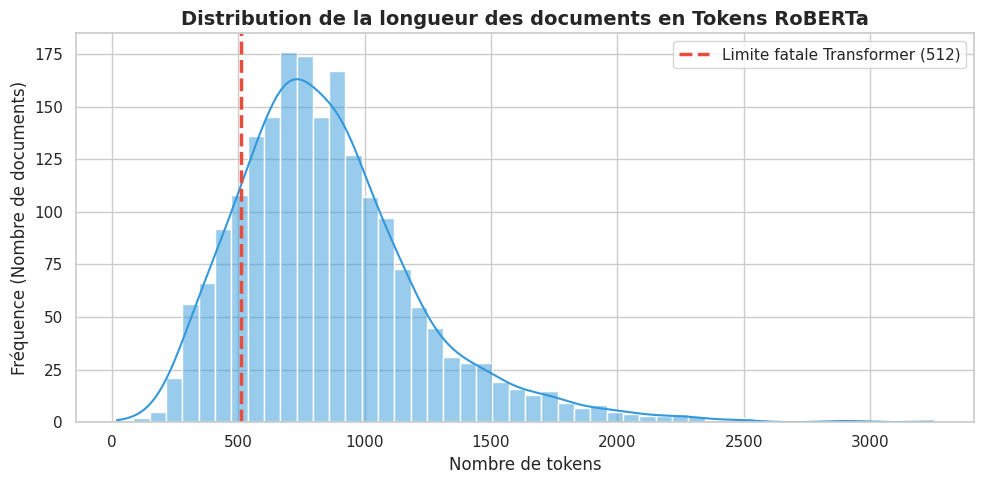

      -> Tokenization Head+Tail ultra-précise en cours...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: siebert/sentiment-roberta-large-english
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1
1,No log,0.107229,0.981250
2,No log,0.169915,0.971875


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

      -> 🎉 Score final siebert/sentiment-roberta-large-english (Test F1) : 0.9750

[6/7] 📊 Génération du graphique des performances...

🏆 CLASSEMENT GÉNÉRAL (Basé sur le Test F1)
        Representation                    Model    CV_F1  Test_F1
Head+Tail (512 tokens) Siebert RoBERTa (Expert)      NaN 0.974984
         Sentence-BERT               Linear SVM 0.915597 0.927478
         Sentence-BERT          Log. Regression 0.910901 0.917487
         Sentence-BERT              PyTorch MLP 0.895023 0.917487
         Sentence-BERT            XGBoost (GPU) 0.886689 0.904979
   TF-IDF (Mots 1-2gr)               Linear SVM 0.842943 0.872493
   TF-IDF (Mots 1-2gr)              PyTorch MLP 0.821976 0.864946
   TF-IDF (Mots 1-2gr)          Log. Regression 0.839070 0.859986
   TF-IDF (Mots 1-2gr)              Naive Bayes 0.829657 0.854985
   TF-IDF (Mots 1-2gr)            XGBoost (GPU) 0.827230 0.845000
    Bag of Words (BoW)              PyTorch MLP 0.832337 0.842381
TF-IDF (Caract. 3-5gr)       

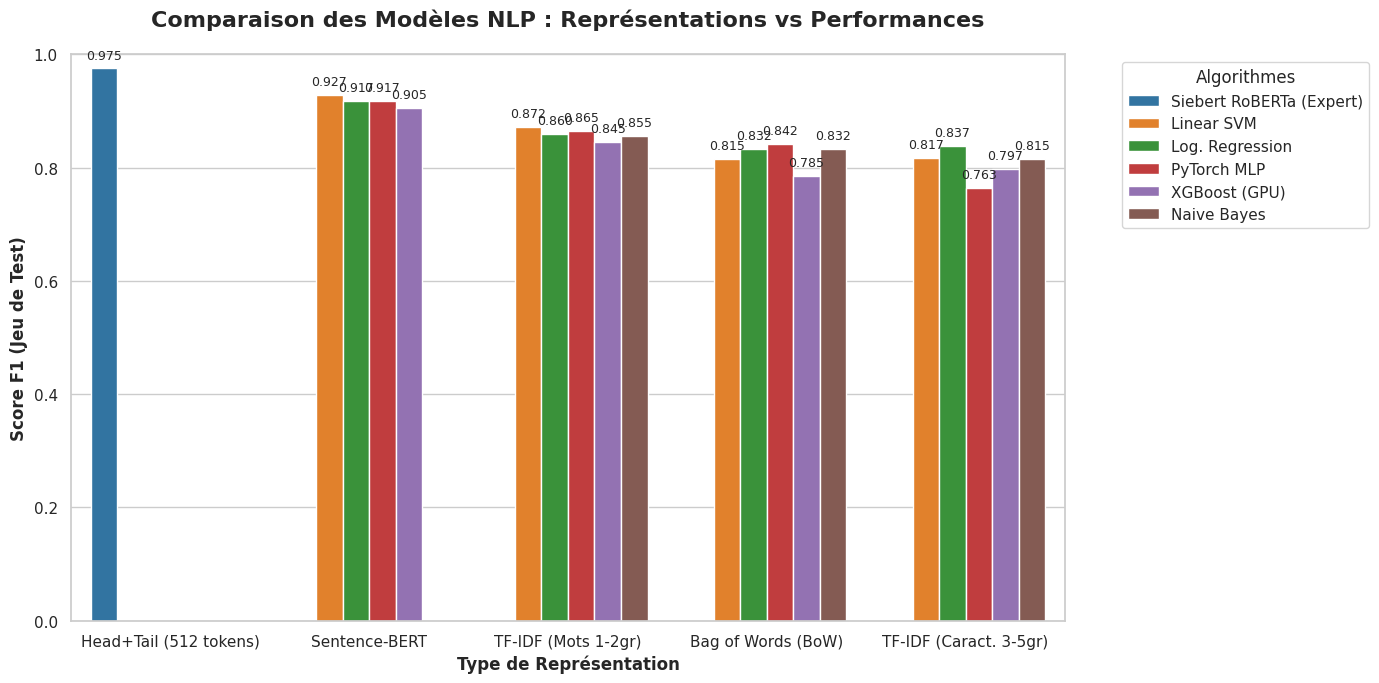


[7/7] 📝 GÉNÉRATION DU FICHIER DE SOUMISSION...
      -> 25000 critiques chargées pour l'évaluation finale.
      -> Tokenization Head+Tail en cours...
      -> Inférence du modèle en cours...

🧐 Aperçu des 3 premières prédictions :
[N] : Story of a man who has unnatural feelings for a pig. Starts out with a opening s...
[P] : Bromwell High is a cartoon comedy. It ran at the same time as some other program...
[N] : Airport '77 starts as a brand new luxury 747 plane is loaded up with valuable pa...

✅ Fichier sauvegardé : submission-movie-1.csv

✅ PIPELINE TERMINÉ AVEC SUCCÈS !


In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"       # Cache le 2ème GPU
os.environ["TOKENIZERS_PARALLELISM"] = "false" # Empêche un warning HuggingFace

import re
import time
import copy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contractions
import nltk
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords

# Scikit-Learn
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score

# XGBoost
import xgboost as xgb

# Deep Learning (PyTorch & HuggingFace)
import torch
import torch.nn as nn
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import Dataset

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)

# ============================================================
# SETUP & DÉTECTION GPU
# ============================================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
num_gpus = torch.cuda.device_count()

print(f"[Setup] Device utilisé : {DEVICE.upper()}")
print(f"[Setup] Nombre de GPUs détectés par PyTorch : {num_gpus}")

if num_gpus > 1:
    print("⚠️ DANGER : PyTorch voit encore plusieurs GPUs ! Le modèle va crasher.")
else:
    print("✅ PARFAIT : Un seul GPU détecté, prêt pour le Deep Learning !")

# ============================================================
# ÉTAPE 1 : ACQUISITION ET ENCODAGE DES DONNÉES
# ============================================================
def load_movies(path):
    print("\n[1/7] Chargement des données brutes...")
    texts, labels_raw = [], []
    classes = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])

    for cls in classes:
        cls_path = os.path.join(path, cls)
        for f in os.listdir(cls_path):
            file_path = os.path.join(cls_path, f)
            if os.path.isfile(file_path):
                with open(file_path, encoding='utf-8', errors='replace') as fh:
                    texts.append(fh.read())
                    labels_raw.append(cls)

    le = LabelEncoder()
    labels_encoded = le.fit_transform(labels_raw)
    print(f"      -> {len(classes)} classes détectées : {list(le.classes_)}")
    return np.array(texts), np.array(labels_encoded), le

# ============================================================
# ÉTAPE 2 : NETTOYAGE (LES CLEANERS)
# ============================================================
class TextCleaner(BaseEstimator, TransformerMixin):
    _NEGATIONS = {"no", "not", "nor", "never", "nobody", "nothing"}

    def __init__(self):
        self.stemmer    = SnowballStemmer('english')
        self.stopwords  = set(stopwords.words('english')) - self._NEGATIONS
        self._html      = re.compile(r'<[^>]+>')
        self._url       = re.compile(r'http\S+|www\S+')
        self._non_alpha = re.compile(r'[^a-z0-9\s]')

    def fit(self, X, y=None): return self
    def transform(self, X, y=None): return[self._clean(str(t)) for t in X]

    def _clean(self, text):
        text = self._html.sub(' ', text.lower())
        text = self._url.sub(' ', text)
        text = contractions.fix(text)
        text = self._non_alpha.sub(' ', text)
        return " ".join(
            self.stemmer.stem(w) for w in text.split()
            if w not in self.stopwords and len(w) > 1
        )

class DeepTextCleaner(BaseEstimator, TransformerMixin):
    def __init__(self):
        self._html   = re.compile(r'<[^>]+>')
        self._url    = re.compile(r'http\S+|www\S+')
        self._spaces = re.compile(r'\s+')

    def fit(self, X, y=None): return self
    def transform(self, X, y=None): return[self._clean(str(t)) for t in X]

    def _clean(self, text):
        text = self._html.sub(' ', text)
        text = self._url.sub(' ', text)
        return self._spaces.sub(' ', text).strip()

# ============================================================
# ÉTAPE 3 : PRÉCALCUL EN MÉMOIRE (SBERT & CLASSIQUE)
# ============================================================
def precompute_sbert(texts_train, texts_val, texts_test, model_name='nomic-ai/nomic-embed-text-v1.5'):
    print(f"\n[3/7] Génération des embeddings SBERT ({model_name}) en mémoire...")

    cleaner = DeepTextCleaner()
    model = SentenceTransformer(model_name, device=DEVICE, trust_remote_code=True)
    model.max_seq_length = 2048

    def encode_texts(texts, desc):
        print(f"      -> Encodage du {desc}...")
        return model.encode(
            cleaner.transform(texts), batch_size=16, show_progress_bar=True,
            convert_to_numpy=True, normalize_embeddings=True
        ).astype(np.float32)

    emb_train = encode_texts(texts_train, "Train set")
    emb_val   = encode_texts(texts_val, "Validation set")
    emb_test  = encode_texts(texts_test, "Test set")

    del model
    if DEVICE == 'cuda': torch.cuda.empty_cache()

    return emb_train, emb_val, emb_test

def precompute_classical_features(X_train, X_test):
    print(f"\n[🔧] Précalcul des matrices classiques (BoW, TF-IDF) en mémoire...")

    # 1. On nettoie le texte UNE SEULE FOIS !
    print("      -> Nettoyage approfondi des textes (Stemming, Stopwords)...")
    cleaner = TextCleaner()
    X_train_clean = cleaner.transform(X_train)
    X_test_clean  = cleaner.transform(X_test)

    vectorizers = {
        "Bag of Words (BoW)": CountVectorizer(min_df=3, max_df=0.9, max_features=15000),
        "TF-IDF (Mots 1-2gr)": TfidfVectorizer(min_df=3, max_df=0.9, max_features=15000, ngram_range=(1, 2), sublinear_tf=True, dtype=np.float32),
        "TF-IDF (Caract. 3-5gr)": TfidfVectorizer(analyzer='char_wb', min_df=3, max_df=0.9, max_features=15000, ngram_range=(3, 5), sublinear_tf=True, dtype=np.float32)
    }

    precomputed_data = {}

    # 2. On vectorise UNE SEULE FOIS pour toutes les CV et modèles !
    for vec_name, vectorizer in vectorizers.items():
        print(f"      -> Vectorisation de : {vec_name}...")
        X_train_vec = vectorizer.fit_transform(X_train_clean)
        X_test_vec  = vectorizer.transform(X_test_clean)

        # SVD spécifique pour accélérer XGBoost (qui déteste les matrices sparses géantes)
        print(f"      -> Réduction de dimension SVD (pour XGBoost) sur {vec_name}...")
        svd = TruncatedSVD(n_components=300, random_state=42)
        X_train_svd = svd.fit_transform(X_train_vec)
        X_test_svd  = svd.transform(X_test_vec)

        precomputed_data[vec_name] = {
            "train": X_train_vec, "test": X_test_vec,
            "train_svd": X_train_svd, "test_svd": X_test_svd
        }

    return precomputed_data

# ============================================================
# ÉTAPE 4 : PYTORCH MLP & MODÈLES CLASSIQUES
# ============================================================
class TorchGPUClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, epochs=30, batch_size=256, lr=3e-3, patience=5):
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.patience = patience

    def fit(self, X, y, eval_set=None):
        if hasattr(X, "toarray"): X = X.toarray()

        if eval_set is None:
            X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
        else:
            X_tr, y_tr = X, y
            X_va, y_va = eval_set[0]
            if hasattr(X_va, "toarray"): X_va = X_va.toarray()

        X_t_train = torch.tensor(X_tr, dtype=torch.float32)
        y_t_train = torch.tensor(y_tr, dtype=torch.long)
        X_t_val   = torch.tensor(X_va, dtype=torch.float32).to(DEVICE)
        y_t_val   = torch.tensor(y_va, dtype=torch.long).to(DEVICE)

        n_classes = len(np.unique(y))
        in_features = X_tr.shape[1]

        self.model_ = nn.Sequential(
            nn.Linear(in_features, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),         nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),          nn.ReLU(),
            nn.Linear(64, n_classes)
        ).to(DEVICE)

        dataset = torch.utils.data.TensorDataset(X_t_train, y_t_train)
        loader  = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        optimizer = torch.optim.AdamW(self.model_.parameters(), lr=self.lr, weight_decay=1e-2)
        scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=self.lr, steps_per_epoch=len(loader), epochs=self.epochs)
        criterion = nn.CrossEntropyLoss()

        best_val_loss = float('inf')
        best_model_weights = None
        epochs_no_improve = 0

        for epoch in range(self.epochs):
            self.model_.train()
            for bx, by in loader:
                bx, by = bx.to(DEVICE), by.to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(self.model_(bx), by)
                loss.backward()
                optimizer.step()
                scheduler.step()

            self.model_.eval()
            with torch.no_grad():
                val_loss = criterion(self.model_(X_t_val), y_t_val).item()

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_weights = copy.deepcopy(self.model_.state_dict())
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= self.patience:
                    break

        if best_model_weights is not None:
            self.model_.load_state_dict(best_model_weights)

        return self

    def predict(self, X):
        if hasattr(X, "toarray"): X = X.toarray()
        self.model_.eval()
        results =[]
        batch_size = 512
        with torch.no_grad():
            for i in range(0, len(X), batch_size):
                chunk = torch.tensor(X[i:i+batch_size], dtype=torch.float32).to(DEVICE)
                preds = torch.argmax(self.model_(chunk), dim=1).cpu()
                results.append(preds)
        return torch.cat(results).numpy()

def run_full_experiments(precomputed_data, y_train, y_test, sbert_train=None, sbert_test=None):
    print(f"\n[4/7] Lancement ULTRA-RAPIDE des modèles (sur données précalculées)...")

    models = {
        "Naive Bayes":      MultinomialNB(),
        "Log. Regression":  LogisticRegression(C=1.0, max_iter=5000, solver='saga', n_jobs=-1, random_state=42),
        "Linear SVM":       LinearSVC(C=1.0, max_iter=5000, dual="auto", random_state=42),
        "PyTorch MLP":      TorchGPUClassifier(epochs=30, lr=3e-3),
        "XGBoost (GPU)":    xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                              subsample=0.8, colsample_bytree=0.5, random_state=42,
                                              tree_method='hist', device='cuda', eval_metric='logloss')
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    results =[]

    print("\n" + "=" * 110)
    print(f"{'REPRÉSENTATION':<28} | {'MODÈLE':<20} | {'F1 (3-Fold CV)':<18} | {'F1 (TEST)':<10}")
    print("=" * 110)

    # A) Boucle sur les matrices précalculées (BoW, TF-IDF)
    for vec_name, data in precomputed_data.items():
        for model_name, clf in models.items():

            # Utilise SVD pour XGBoost pour éviter l'explosion de mémoire, matrice classique pour les autres
            X_tr = data["train_svd"] if model_name == "XGBoost (GPU)" else data["train"]
            X_te = data["test_svd"]  if model_name == "XGBoost (GPU)" else data["test"]

            # Naive Bayes ne supporte pas les valeurs négatives générées par SVD. On gère l'erreur potentielle.
            if model_name == "Naive Bayes" and "svd" in str(type(X_tr)).lower():
                continue

            try:
                cv_scores = cross_val_score(clf, X_tr, y_train, cv=cv, scoring='f1_weighted', n_jobs=1)
                clf.fit(X_tr, y_train)
                test_f1 = f1_score(y_test, clf.predict(X_te), average='weighted')
                print(f"{vec_name:<28} | {model_name:<20} | {cv_scores.mean():.4f}             | {test_f1:.4f}")
                results.append({'Representation': vec_name, 'Model': model_name, 'CV_F1': cv_scores.mean(), 'Test_F1': test_f1})
            except Exception as e:
                print(f"{vec_name:<28} | {model_name:<20} | ❌ ERREUR ({e})")

    # B) SBERT (Précalculé en amont)
    if sbert_train is not None and sbert_test is not None:
        for model_name, clf in models.items():
            if model_name == "Naive Bayes": continue # SBERT a des valeurs négatives incompatibles

            try:
                cv_scores = cross_val_score(clf, sbert_train, y_train, cv=cv, scoring='f1_weighted', n_jobs=1)
                clf.fit(sbert_train, y_train)
                test_f1 = f1_score(y_test, clf.predict(sbert_test), average='weighted')
                print(f"{'Sentence-BERT':<28} | {model_name:<20} | {cv_scores.mean():.4f}             | {test_f1:.4f}")
                results.append({'Representation': 'Sentence-BERT', 'Model': model_name, 'CV_F1': cv_scores.mean(), 'Test_F1': test_f1})
            except Exception as e:
                print(f"{'Sentence-BERT':<28} | {model_name:<20} | ❌ ERREUR")

    return pd.DataFrame(results)

# ============================================================
# ÉTAPE 4.5 : ANALYSE DES LONGUEURS DE TOKENS
# ============================================================
def analyze_token_lengths(texts, tokenizer):
    print("\n[📊] Analyse de la distribution du nombre de tokens (avant Head+Tail)...")
    encodings = tokenizer(texts, truncation=False)
    lengths =[len(ids) for ids in encodings['input_ids']]

    mean_len = np.mean(lengths)
    median_len = np.median(lengths)
    p95 = np.percentile(lengths, 95)
    max_len = np.max(lengths)

    print(f"      -> Moyenne : {mean_len:.0f} tokens")
    print(f"      -> Médiane : {median_len:.0f} tokens")
    print(f"      -> 95ème percentile : {p95:.0f} tokens")
    print(f"      -> Maximum : {max_len} tokens")

    plt.figure(figsize=(10, 5))
    sns.histplot(lengths, bins=50, kde=True, color='#3498db')
    plt.axvline(512, color='#e74c3c', linestyle='dashed', linewidth=2.5, label='Limite fatale Transformer (512)')
    plt.title('Distribution de la longueur des documents en Tokens RoBERTa', fontsize=14, fontweight='bold')
    plt.xlabel('Nombre de tokens', fontsize=12)
    plt.ylabel('Fréquence (Nombre de documents)', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ============================================================
# ÉTAPE 5 : FINE-TUNING DU TRANSFORMER (RoBERTa avec Head+Tail)
# ============================================================
def fine_tune_transformer(X_train, y_train, X_val, y_val, X_test, y_test, model_name="siebert/sentiment-roberta-large-english"):
    print(f"\n[5/7] 🚀 Fine-Tuning de l'Arme Nucléaire ({model_name})...")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    cleaner = DeepTextCleaner()

    # Analyse préalable de la longueur des tokens
    all_texts = list(X_train) + list(X_val) + list(X_test)
    analyze_token_lengths(cleaner.transform(all_texts), tokenizer)

    def make_ds(texts, labels):
        clean_texts = cleaner.transform(texts)
        encodings = tokenizer(clean_texts, truncation=False)

        new_input_ids =[]
        new_attention_mask =[]

        for ids in encodings['input_ids']:
            if len(ids) > 512:
                final_ids = ids[:128] + ids[-384:]
                final_mask =[1] * 512
            else:
                pad_len = 512 - len(ids)
                final_ids = ids +[tokenizer.pad_token_id] * pad_len
                final_mask = [1] * len(ids) + [0] * pad_len

            new_input_ids.append(final_ids)
            new_attention_mask.append(final_mask)

        return Dataset.from_dict({
            'input_ids': new_input_ids,
            'attention_mask': new_attention_mask,
            'label': labels
        })

    print("      -> Tokenization Head+Tail ultra-précise en cours...")
    ds_train = make_ds(X_train, y_train)
    ds_val   = make_ds(X_val, y_val)
    ds_test  = make_ds(X_test, y_test)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(DEVICE)

    args = TrainingArguments(
        output_dir="./tmp_transformer",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=5e-6,
        warmup_ratio=0.1,
        per_device_train_batch_size=8, # ⚠️ Passe à 4 avec gradient_accumulation_steps=2 si erreur OOM
        per_device_eval_batch_size=8,
        num_train_epochs=5,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        fp16=(DEVICE == 'cuda'),
        report_to="none"
    )

    def compute_metrics(eval_pred):
        return {"f1": f1_score(eval_pred.label_ids, np.argmax(eval_pred.predictions, axis=-1), average='weighted')}

    trainer = Trainer(
        model=model, args=args, train_dataset=ds_train, eval_dataset=ds_val,
        compute_metrics=compute_metrics, callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
    )

    trainer.train()
    test_f1 = trainer.evaluate(ds_test)['eval_f1']
    print(f"      -> 🎉 Score final {model_name} (Test F1) : {test_f1:.4f}")

    df_transformer = pd.DataFrame([{'Representation': 'Head+Tail (512 tokens)', 'Model': 'Siebert RoBERTa (Expert)', 'CV_F1': np.nan, 'Test_F1': test_f1}])

    return df_transformer, trainer, tokenizer, cleaner

# ============================================================
# ÉTAPE 6 : CONSOLIDATION ET PLOT
# ============================================================
def plot_final_benchmarks(df_classical, df_transformer):
    print("\n[6/7] 📊 Génération du graphique des performances...")

    df_final = pd.concat([df_classical, df_transformer], ignore_index=True)
    df_final = df_final.sort_values(by='Test_F1', ascending=False)

    print("\n" + "="*85)
    print("🏆 CLASSEMENT GÉNÉRAL (Basé sur le Test F1)")
    print("="*85)
    print(df_final.to_string(index=False))

    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    ax = sns.barplot(data=df_final, x='Representation', y='Test_F1', hue='Model', palette='tab10')

    plt.title('Comparaison des Modèles NLP : Représentations vs Performances', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Type de Représentation', fontsize=12, fontweight='bold')
    plt.ylabel('Score F1 (Jeu de Test)', fontsize=12, fontweight='bold')
    plt.ylim(0.0, 1.0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Algorithmes")

    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=9, xytext=(0, 5), textcoords='offset points')

    plt.tight_layout()
    plt.show()

def generate_submission(trainer, tokenizer, cleaner):
    print("\n[7/7] 📝 GÉNÉRATION DU FICHIER DE SOUMISSION...")

    test_file_path = "./testSentiment.txt"

    if not os.path.exists(test_file_path):
        print(f"      ⚠️ Fichier de test introuvable à : {test_file_path}")
        return

    with open(test_file_path, "r", encoding="utf-8") as f:
        test_texts =[line.strip() for line in f if line.strip()]

    print(f"      -> {len(test_texts)} critiques chargées pour l'évaluation finale.")
    print("      -> Tokenization Head+Tail en cours...")

    clean_test_texts = cleaner.transform(test_texts)
    encodings = tokenizer(clean_test_texts, truncation=False)

    new_input_ids =[]
    new_attention_mask =[]

    for ids in encodings['input_ids']:
        if len(ids) > 512:
            final_ids = ids[:128] + ids[-384:]
            final_mask = [1] * 512
        else:
            pad_len = 512 - len(ids)
            final_ids = ids +[tokenizer.pad_token_id] * pad_len
            final_mask = [1] * len(ids) + [0] * pad_len

        new_input_ids.append(final_ids)
        new_attention_mask.append(final_mask)

    ds_final_test = Dataset.from_dict({
        'input_ids': new_input_ids,
        'attention_mask': new_attention_mask
    })

    print("      -> Inférence du modèle en cours...")
    predictions_output = trainer.predict(ds_final_test)
    y_pred_numeric = np.argmax(predictions_output.predictions, axis=-1)

    mapping = {0: 'N', 1: 'P'} # Le LabelEncoder mappe 'N' sur 0 et 'P' sur 1
    y_pred_chars = [mapping[pred] for pred in y_pred_numeric]

    print("\n🧐 Aperçu des 3 premières prédictions :")
    for i in range(3):
        extrait = test_texts[i][:80] + "..."
        print(f"[{y_pred_chars[i]}] : {extrait}")

    submission_df = pd.DataFrame(y_pred_chars)
    submission_filename = "submission-movie-1.csv"
    submission_df.to_csv(submission_filename, index=False, header=False)
    print(f"\n✅ Fichier sauvegardé : {submission_filename}")

# ============================================================
# EXÉCUTION PRINCIPALE (MAIN)
# ============================================================
DATA_PATH = "./movies1000"

if __name__ == "__main__":
    if os.path.exists(DATA_PATH):
        print("="*80)
        print("🚀 DÉMARRAGE DU BENCHMARK NLP GLOBAL")
        print("="*80)

        # 1. Chargement
        X, y, label_encoder = load_movies(DATA_PATH)

        # 2. Séparation
        print("\n[2/7] Séparation des données (Train / Validation / Test)...")
        X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
        X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42)
        print(f"      -> Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

        # 3. SBERT (En mémoire uniquement)
        sbert_train, sbert_val, sbert_test = precompute_sbert(X_train, X_val, X_test)

        # 3.5 Précalcul des matrices classiques (BoW, TF-IDF, TF-IDF Caractères) en mémoire
        precomputed_classical = precompute_classical_features(X_train, X_test)

        # 4. Modèles Classiques (Alimentés instantanément avec les matrices en RAM)
        df_classical = run_full_experiments(precomputed_classical, y_train, y_test, sbert_train, sbert_test)

        # 5. Transformer Fine-Tuning (Analyse de tokens + Head & Tail)
        df_transformer, best_trainer, best_tokenizer, best_cleaner = fine_tune_transformer(X_train, y_train, X_val, y_val, X_test, y_test)

        # 6. Benchmark
        plot_final_benchmarks(df_classical, df_transformer)

        # 7. Submision
        generate_submission(best_trainer, best_tokenizer, best_cleaner)

        print("\n✅ PIPELINE TERMINÉ AVEC SUCCÈS !")
    else:
        print(f"⚠️ Chemin introuvable : {DATA_PATH}. Veuillez vérifier le chemin.")